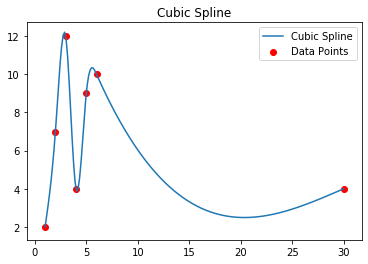

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,2,3,4,5,6,30], dtype=float)
y = np.array([2,7,12,4,9,10,4], dtype=float)
# sort x and y together

n = len(x)
#length between points
h = np.diff(x)

a = np.zeros(n)
b = np.zeros(n)
c = np.zeros(n)
d = np.zeros(n)

#boundaries
b[0] = 1
b[-1] = 1
d[0] = 0
d[-1] = 0

for i in range(1, n-1):
    a[i] = h[i-1]
    b[i] = 2 * (h[i-1] + h[i])
    c[i] = h[i]
    
    d[i] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

#solve
for i in range(1, n):
    w = a[i] / b[i-1]
    b[i] = b[i] - w * c[i-1]
    d[i] = d[i] - w * d[i-1]

M = np.zeros(n)
M[-1] = d[-1] / b[-1]

for i in range(n-2, -1, -1):
    M[i] = (d[i] - c[i] * M[i+1]) / b[i]

def evaluate_spline(x_val, x, y, M, h):
    # find interval
    i = np.searchsorted(x, x_val) - 1
    i = max(0, min(i, len(x)-2))

    xi, xi1 = x[i], x[i+1]
    hi = h[i]

    term1 = M[i] * (xi1 - x_val)**3 / (6 * hi)
    term2 = M[i+1] * (x_val - xi)**3 / (6 * hi)
    term3 = (y[i] - M[i] * hi**2 / 6) * (xi1 - x_val) / hi
    term4 = (y[i+1] - M[i+1] * hi**2 / 6) * (x_val - xi) / hi

    return term1 + term2 + term3 + term4

#plot
x_dense = np.linspace(x[0], x[-1], 200)
y_spline = [evaluate_spline(xi, x, y, M, h) for xi in x_dense]

plt.plot(x_dense, y_spline, label="Cubic Spline")
plt.scatter(x, y, color='red', label="Data Points")
plt.legend()
plt.title("Cubic Spline")
plt.show()